In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
import os
print(os.getcwd())

C:\Users\practicanteit3\Documents\MBA\notebooks


In [3]:
df = pd.read_csv('../processed/alto.csv', sep=';')
df_historial = pd.read_csv('../raw/ConsumoMasivoFiltro.csv', sep=';',low_memory=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2355 entries, 0 to 2354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente             2355 non-null   int64  
 1   frecuencia          2355 non-null   int64  
 2   recencia            2355 non-null   int64  
 3   ticket_promedio     2355 non-null   float64
 4   ticket              2355 non-null   float64
 5   referencias_unicas  2355 non-null   int64  
 6   margen_promeido     2355 non-null   float64
 7   margen              2355 non-null   float64
 8   avg_descuento       2355 non-null   float64
 9   cl_value            2355 non-null   float64
 10  linea_favorita      2355 non-null   object 
 11  marca_favorita      2355 non-null   object 
dtypes: float64(6), int64(4), object(2)
memory usage: 220.9+ KB


In [5]:
X = df[['frecuencia', 'ticket_promedio','cl_value']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


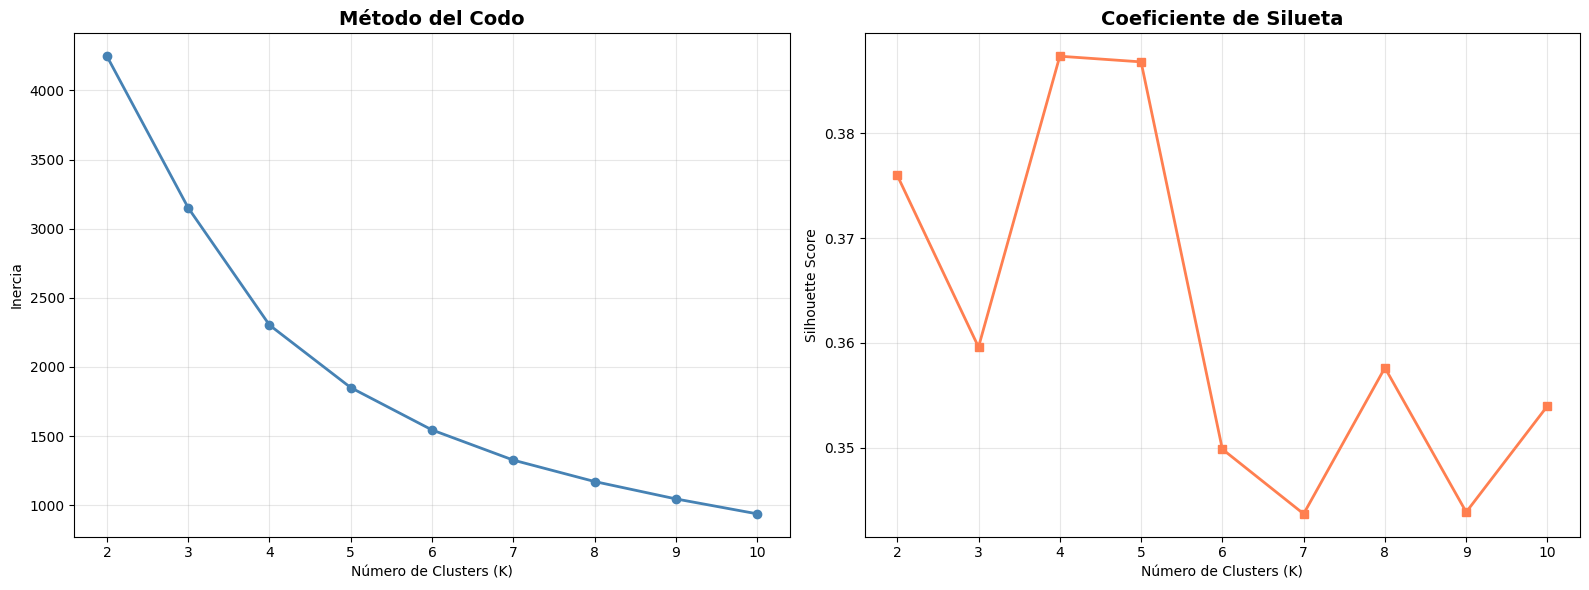


📋 Resumen de resultados:
  K |      Inercia |  Silueta
------------------------------
  2 |     4,247.18 |   0.3760
  3 |     3,150.93 |   0.3596
  4 |     2,303.12 |   0.3874
  5 |     1,850.73 |   0.3868
  6 |     1,544.69 |   0.3498
  7 |     1,326.61 |   0.3437
  8 |     1,171.74 |   0.3576
  9 |     1,046.11 |   0.3438
 10 |       938.16 |   0.3540


In [6]:
# Evaluamos de 2 a 10 clusters
rango_k = range(2, 11)
inercias = []
siluetas = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_scaled, kmeans.labels_))

# Graficamos el Método del Codo y Silueta juntos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico del Codo
ax1.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Método del Codo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(range(2, 11))
ax1.grid(True, alpha=0.3)

# Gráfico de Silueta
ax2.plot(rango_k, siluetas, marker='s', color='coral', linewidth=2)
ax2.set_title('Coeficiente de Silueta', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(range(2, 11))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n📋 Resumen de resultados:")
print(f"{'K':>3} | {'Inercia':>12} | {'Silueta':>8}")
print("-" * 30)
for k, iner, sil in zip(rango_k, inercias, siluetas):
    print(f"{k:>3} | {iner:>12,.2f} | {sil:>8.4f}")


In [7]:
# Aplicamos KMeans con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters


# Veamos cuántos clientes hay en cada grupo
print("Distribución de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())
df_escalados = pd.DataFrame(X_scaled, columns=['frecuencia','ticket_promedio','cl_value'])
df_escalados['cluster'] = clusters

Distribución de clientes por cluster:
cluster
0     597
1     735
2    1023
Name: count, dtype: int64


,frecuencia,ticket_promedio,cl_value
count,3.00,3.00,3.00
mean,20.29,"43,110.36","868,122.88"
std,10.01,"5,255.62","421,456.90"
min,13.44,"38,110.39","593,703.10"
25%,14.55,"40,371.09","625,487.58"
50%,15.65,"42,631.79","657,272.06"
75%,23.72,"45,610.34","1,005,332.77"
max,31.79,"48,588.89","1,353,393.47"


,frecuencia,ticket_promedio,cl_value
cluster,,,
0,13.44,"48,588.89","657,272.06"
1,31.79,"42,631.79","1,353,393.47"
2,15.65,"38,110.39","593,703.10"


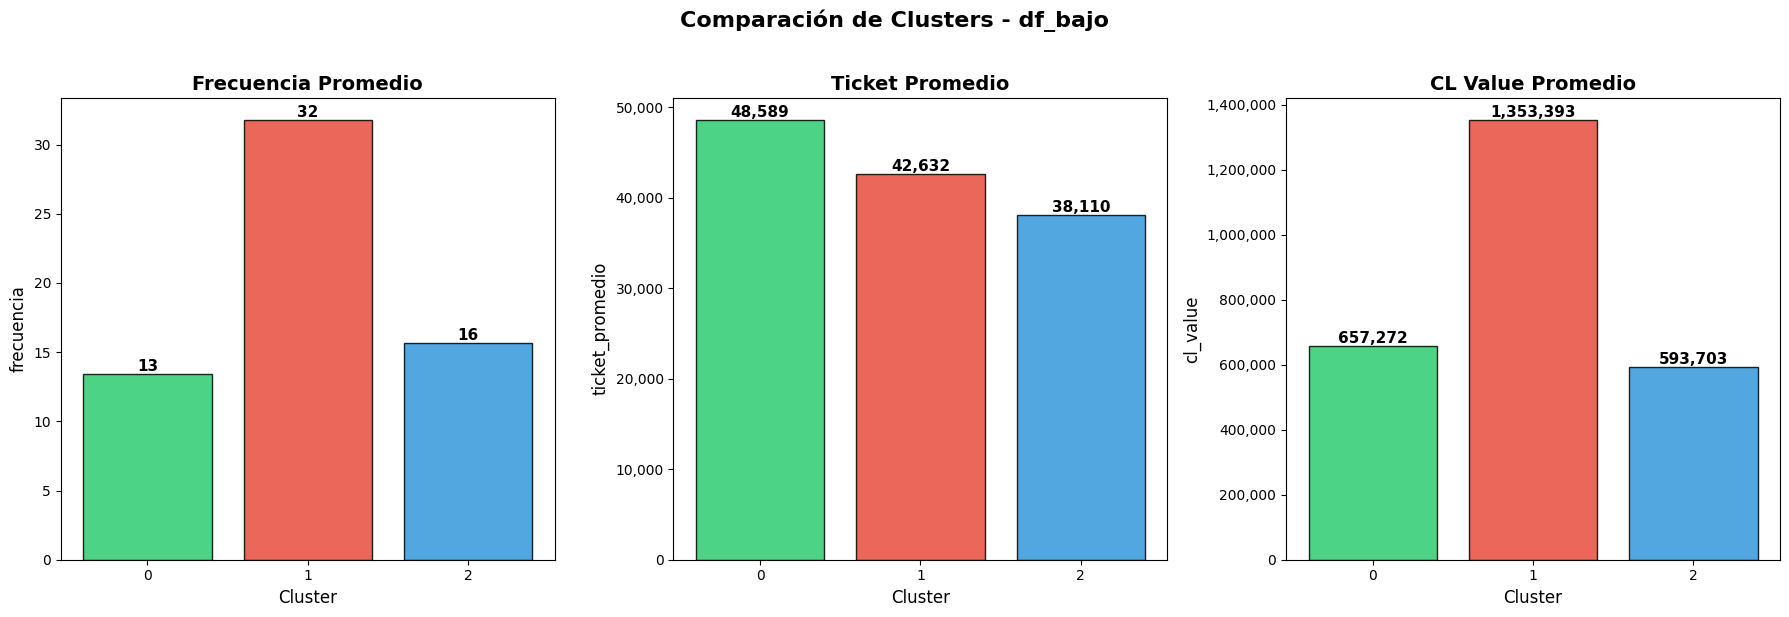

In [8]:
# Calcular promedios por cluster
resumen = df.groupby('cluster')[['frecuencia', 'ticket_promedio', 'cl_value']].mean()

display(resumen.describe())
display(resumen)


# Crear el barplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colores = ['#2ecc71', '#e74c3c', '#3498db']
variables = ['frecuencia', 'ticket_promedio', 'cl_value']
titulos = ['Frecuencia Promedio', 'Ticket Promedio', 'CL Value Promedio']

for i, (var, titulo) in enumerate(zip(variables, titulos)):
    bars = axes[i].bar(
        resumen.index.astype(str),
        resumen[var],
        color=colores,
        edgecolor='black',
        alpha=0.85
    )
    
    # Agregar valores encima de cada barra
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
    
    axes[i].set_title(titulo, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=12)
    axes[i].set_ylabel(var, fontsize=12)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Comparación de Clusters - df_bajo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [9]:
def catalogar_clusters(df):
    """
    Esta función toma un dataframe con clientes ya clusterizados,
    calcula las métricas promedio por cluster, las compara contra
    el promedio general y asigna un nombre descriptivo a cada cluster.
    
    Parámetros:
    -----------
    df : DataFrame con columnas: frecuencia, ticket_promedio, cl_value, cluster
    
    Retorna:
    --------
    df : DataFrame original con nueva columna 'nombre_cluster'
    resumen : DataFrame con las métricas y nombres por cluster
    """
    
    # ================================================
    # PASO 1: Calcular el promedio GENERAL (todos los clientes juntos)
    # ================================================
    # Esto es nuestro "punto de referencia" para comparar cada cluster
    
    promedio_general = {
        'frecuencia_gral': df['frecuencia'].mean(),
        'ticket_promedio_gral': df['ticket_promedio'].mean(),
        'cl_value_gral': df['cl_value'].mean()
    }
    
    # ================================================
    # PASO 2: Calcular promedios POR CLUSTER
    # ================================================
    # Agrupamos por cluster y sacamos el promedio de cada métrica
    
    resumen = df.groupby('cluster').agg(
        cantidad_clientes=('cliente', 'count'),
        frecuencia_prom=('frecuencia', 'mean'),
        ticket_promedio_prom=('ticket_promedio', 'mean'),
        cl_value_prom=('cl_value', 'mean')
    ).reset_index()
    
    # ================================================
    # PASO 3: Comparar cada cluster contra el promedio general
    # ================================================
    # Creamos columnas que nos dicen si el cluster está
    # POR ENCIMA o POR DEBAJO del promedio general
    
    resumen['freq_vs_gral'] = resumen['frecuencia_prom'].apply(
        lambda x: '⬆️ Alta' if x > promedio_general['frecuencia_gral'] else '⬇️ Baja'
    )
    
    resumen['ticket_vs_gral'] = resumen['ticket_promedio_prom'].apply(
        lambda x: '⬆️ Alto' if x > promedio_general['ticket_promedio_gral'] else '⬇️ Bajo'
    )
    
    resumen['clv_vs_gral'] = resumen['cl_value_prom'].apply(
        lambda x: '⬆️ Alto' if x > promedio_general['cl_value_gral'] else '⬇️ Bajo'
    )
    
    # ================================================
    # PASO 4: Asignar nombres basados en la comparación
    # ================================================
    # La lógica: combinamos las tres métricas para crear
    # un nombre que describa el comportamiento del cluster
    
    def asignar_nombre(row):
        freq = row['frecuencia_prom'] > promedio_general['frecuencia_gral']
        ticket = row['ticket_promedio_prom'] > promedio_general['ticket_promedio_gral']
        clv = row['cl_value_prom'] > promedio_general['cl_value_gral']
        
        # Todas altas
        if freq and ticket and clv:
            return 'Estrella'
        
        # Frecuencia alta pero ticket bajo
        elif freq and not ticket:
            return 'Frecuente Moderado'
        
        # Ticket alto pero frecuencia baja
        elif not freq and ticket:
            return 'Esporádico Valioso'
        
        # CLV alto con alguna combinación
        elif clv and (freq or ticket):
            return 'Alto Valor'
        
        # Todo por debajo del promedio
        elif not freq and not ticket and not clv:
            return 'Básico'
        
        # Caso intermedio
        else:
            return 'Intermedio'
    
    resumen['nombre_cluster'] = resumen.apply(asignar_nombre, axis=1)
    
    # ================================================
    # PASO 5: Agregar el nombre al dataframe original
    # ================================================
    # Creamos un diccionario {numero_cluster: nombre}
    # y lo mapeamos a cada registro
    
    mapa_nombres = dict(zip(resumen['cluster'], resumen['nombre_cluster']))
    df['nombre_cluster'] = df['cluster'].map(mapa_nombres)
    
    # ================================================
    # PASO 6: Mostrar resumen bonito
    # ================================================
    
    
    
    return df, resumen


# ================================================
# 🚀 EJECUCIÓN
# ================================================

df, resumen = catalogar_clusters(df)


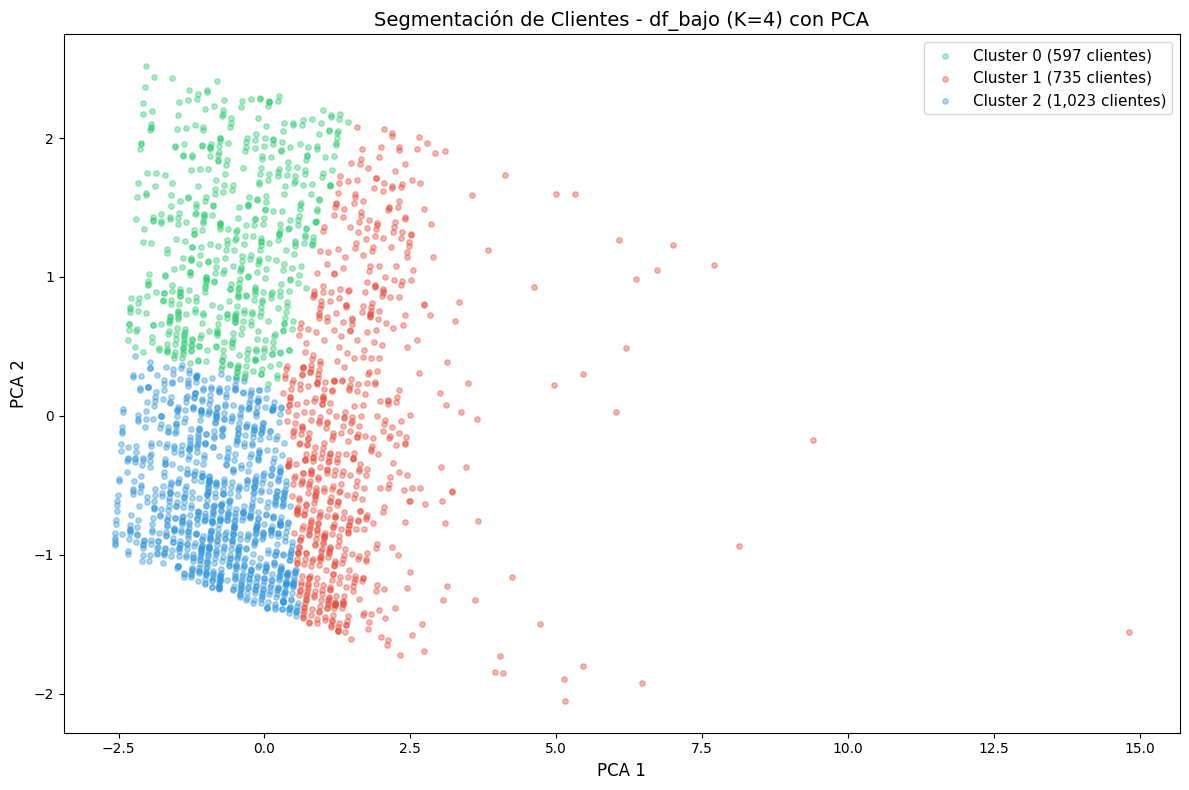

In [10]:
from sklearn.decomposition import PCA

df = df.reset_index(drop=True)
df_escalados = df_escalados.reset_index(drop=True)

df_escalados = df_escalados.drop(columns=['pca1', 'pca2'], errors='ignore')

pca = PCA(n_components=2)

# ✅ Las 3 variables CORRECTAS sin repetir
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))

colores = ['#2ecc71', '#e74c3c', '#3498db']
nombres = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster in range(3):
    mask = df['cluster'] == cluster
    ax.scatter(df.loc[mask, 'pca1'],
               df.loc[mask, 'pca2'],
               c=colores[cluster],
               label=f'{nombres[cluster]} ({mask.sum():,} clientes)',
               alpha=0.4,
               s=15)

ax.set_xlabel('PCA 1', fontsize=12)
ax.set_ylabel('PCA 2', fontsize=12)
ax.set_title('Segmentación de Clientes - df_bajo (K=4) con PCA', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [11]:
info = pca.components_

info = pd.DataFrame(info, columns = ['frecuencia', 'ticket_promedio','cl_value'])
info

,frecuencia,ticket_promedio,cl_value
0,0.69,0.13,0.71
1,-0.22,0.97,0.03


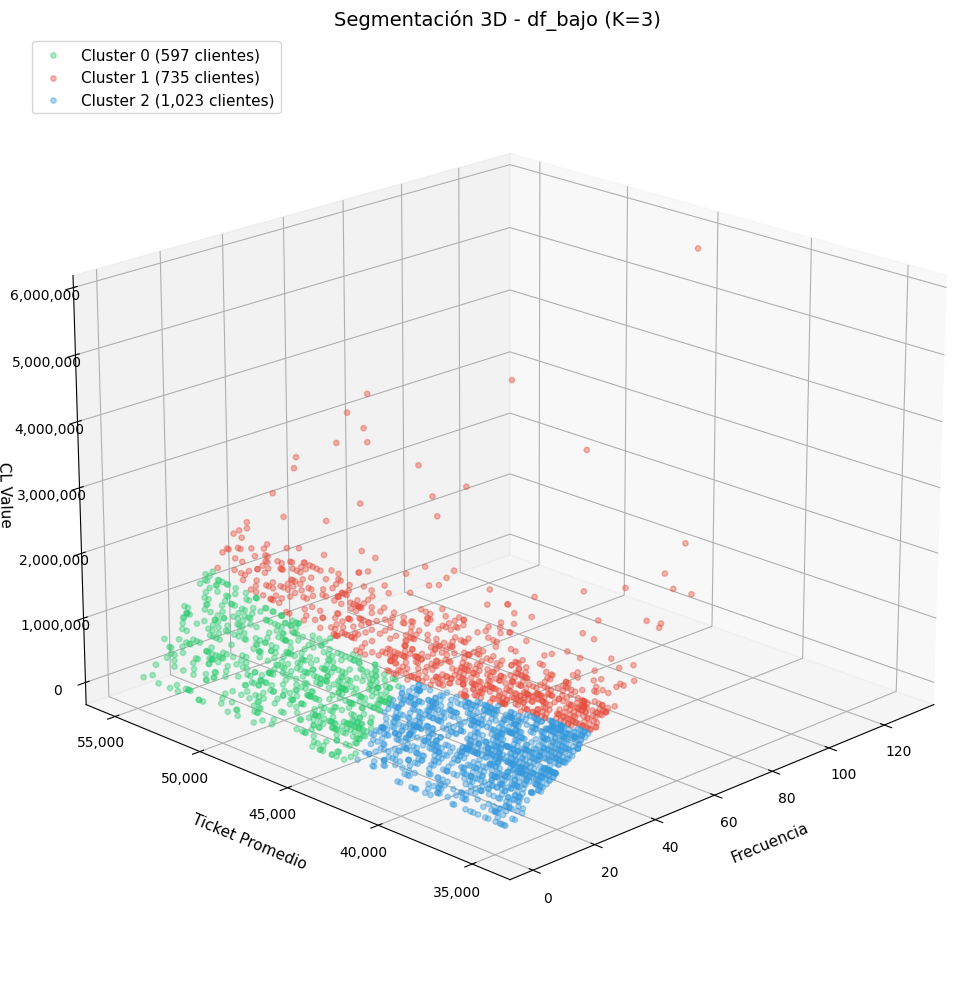

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

pca1=PCA(n_components=3)

X_pca1 = pca1.fit_transform(df[['frecuencia','ticket_promedio','cl_value']])


fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colores = ['#2ecc71', '#e74c3c', '#3498db','#3412f1']
nombres = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster in range(3):
    mask = df['cluster'] == cluster
    ax.scatter(df.loc[mask, 'frecuencia'],
               df.loc[mask, 'ticket_promedio'],
               df.loc[mask, 'cl_value'],
               c=colores[cluster],
               label=f'{nombres[cluster]} ({mask.sum():,} clientes)',
               alpha=0.4,
               s=15)

ax.set_xlabel('Frecuencia', fontsize=11, labelpad=10)
ax.set_ylabel('Ticket Promedio', fontsize=11, labelpad=10)
ax.set_zlabel('CL Value', fontsize=11, labelpad=10)
ax.set_title('Segmentación 3D - df_bajo (K=3)', fontsize=14)

# Formato de números con comas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.legend(fontsize=11, loc='upper left')

# Ángulo de visualización
ax.view_init(elev=25, azim=45)

plt.tight_layout()
# Agrega esta línea ANTES de plt.show()

# Ángulo 1: Vista elevada
ax.view_init(elev=30, azim=45)

# Ángulo 2: Vista lateral
ax.view_init(elev=15, azim=120)

# Ángulo 3: Vista frontal
ax.view_init(elev=0, azim=0)

# Ángulo 4: Vista de pájaro (desde arriba)
ax.view_init(elev=90, azim=0)

# Ángulo 5: Vista diagonal
ax.view_init(elev=20, azim=225)

plt.show()


In [13]:
df[df['cluster']==0].describe()

,cliente,frecuencia,recencia,ticket_promedio,ticket,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,cluster,pca1,pca2
count,597.00,597.00,597.00,597.00,597.00,597.00,597.00,597.00,597.00,597.00,597.00,597.00,597.00
mean,"420,340,518.84",13.44,27.45,"48,588.89","1,929,747.67",12.25,"28,101.92","1,124,675.35",0.01,"657,272.06",0.00,-0.58,1.22
std,"473,637,029.52",5.88,21.76,"3,454.11","1,492,378.79",7.65,"3,520.06","900,400.12",0.01,"301,796.44",0.00,0.88,0.58
min,"1,593,095.00",2.00,1.00,"43,152.25","86,890.76",1.00,"17,919.01","40,813.69",0.00,"86,890.76",0.00,-2.34,0.23
25%,"32,392,429.00",9.00,11.00,"45,528.48","936,268.52",6.00,"25,624.29","537,644.00",0.00,"423,252.99",0.00,-1.26,0.72
50%,"71,189,227.00",14.00,19.00,"48,409.00","1,610,652.11",11.00,"27,793.52","906,697.00",0.00,"658,891.74",0.00,-0.57,1.20
75%,"1,007,318,897.00",18.00,43.00,"51,680.70","2,448,970.41",16.00,"30,280.49","1,419,054.16",0.01,"878,212.84",0.00,0.07,1.70
max,"1,193,512,102.00",25.00,82.00,"55,235.16","10,844,945.27",45.00,"38,635.12","6,719,499.90",0.08,"1,374,421.33",0.00,1.44,2.52


In [14]:
df.head()

,cliente,frecuencia,recencia,ticket_promedio,ticket,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita,cluster,nombre_cluster,pca1,pca2
0,561141,34,11,"40,185.22","3,697,040.63",13,"22,014.24","2,025,310.23",0.02,"1,366,297.63",MANGANESO,TRONEX,1,Estrella,1.67,-0.60
1,567561,32,11,"44,368.80","4,658,723.65",22,"26,196.14","2,750,594.53",0.00,"1,419,801.49",MANGANESO,TRONEX,1,Estrella,1.72,0.16
2,594642,11,12,"36,830.84","1,252,248.42",17,"20,378.78","692,878.65",0.00,"405,139.19",BOMBILLAS,SB,2,Básico,-1.41,-0.75
3,688801,19,8,"40,048.55","1,922,330.20",10,"22,740.67","1,091,552.32",0.02,"760,922.37",MANGANESO,TRONEX,2,Básico,-0.26,-0.35
4,781062,26,28,"34,717.28","2,395,492.64",17,"19,430.15","1,340,680.03",0.00,"902,649.40",BOMBILLAS,SB,2,Básico,0.30,-1.39


## Analisis de canasta de compra

In [15]:
df_mba = pd.merge(df_historial, df, on='cliente', how = 'inner')
df_mba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169312 entries, 0 to 169311
Data columns (total 46 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   factura              169312 non-null  object 
 1   cliente              169312 non-null  int64  
 2   nombrecliente        169312 non-null  object 
 3   tipocliente          169312 non-null  object 
 4   fechafactura         169312 non-null  object 
 5   referencia           169312 non-null  object 
 6   nombrereferencia     169312 non-null  object 
 7   cantidad             169312 non-null  float64
 8   preciounitario       169312 non-null  float64
 9   costounitario        169312 non-null  float64
 10  montoventa           169312 non-null  float64
 11  montoventapesos      169312 non-null  float64
 12  costoventapesos      169312 non-null  float64
 13  valordescuento       169312 non-null  float64
 14  unidadnegocios       169312 non-null  int64  
 15  centrocostos     

In [16]:
df_mba.head()

,factura,cliente,nombrecliente,tipocliente,fechafactura,referencia,nombrereferencia,cantidad,preciounitario,costounitario,...,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita,cluster,nombre_cluster,pca1,pca2
0,HHME001315744,70140546,JAVIER ALEXANDER TABARES GAVIRIA,TAT CENTRO,2025-02-13 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,3.00,"14,621.85","5,413.89",...,"26,121.57","1,436,686.56",0.00,"1,220,171.48",MANGANESO,TRONEX,1,Estrella,1.07,0.71
1,HHME001310233,43869209,DIANA MILENA GALVIS GOMEZ,TAT CENTRO,2025-02-05 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,1.00,"14,621.85","5,413.89",...,"20,324.32","2,764,107.45",0.00,"997,218.74",BOMBILLAS,TRONEX,1,Estrella,0.56,-1.03
2,HHME001213685,22032068,BERTHA LIGIA MONSALVE AMAYA,TAT CENTRO,2024-07-31 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,4.00,"13,907.56","5,413.89",...,"24,152.29","1,618,203.21",0.00,"528,712.96",MANGANESO,TRONEX,2,Básico,-1.00,-0.13
3,HHME001244420,15362224,MIGUEL ANGEL GUZMAN GONZALEZ,TAT CENTRO,2024-10-01 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,2.00,"13,907.56","5,413.89",...,"21,110.12","2,828,755.75",0.02,"665,273.42",OTROS,TRONEX,2,Básico,-0.54,-0.86
4,HHME001301114,43419376,CELIA DOLLY GARCIA HENAO,TAT CENTRO,2025-01-21 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,3.00,"14,621.85","5,413.89",...,"25,249.25","3,938,882.73",0.00,"1,630,515.53",ALKALINAS,TRONEX,1,Estrella,2.49,-0.61


In [17]:
basket = df_mba.groupby('factura')['referencia'].apply(list)
indices = basket.index.tolist()

In [18]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules

te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
df_mba_analysis = pd.DataFrame(te_ary,columns = te.columns_, index = indices )



In [19]:
df_mba_analysis = apriori(df_mba_analysis, min_support= 0.1, use_colnames=True)
df_mba_analysis['productos'] = df_mba_analysis['itemsets'].apply( lambda x: len(x)) 
df_mba_analysis.sort_values(by='support', ascending=False)

,support,itemsets,productos
7,0.33,(TRAAR6EHDR1),1
5,0.31,(TRAALR6ALB2),1
2,0.25,(TRAAALR03ALB2),1
4,0.23,(TRAAAR03EHDBLK),1
9,0.22,(TRDR20RJBLK180),1
10,0.18,"(TRAALR6ALB2, TRAAALR03ALB2)",2
11,0.17,"(TRAAR6EHDR1, TRAAAR03EHDBLK)",2
6,0.13,(TRAAR6EHDB2),1
8,0.12,(TRDLR20ALB2),1
1,0.12,(SLBSLE),1


In [20]:
reglas = association_rules(df_mba_analysis,metric='confidence', min_threshold=0.5)

In [21]:
reglas

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TRAALR6ALB2),(TRAAALR03ALB2),0.31,0.25,0.18,0.57,2.31,1.00,0.10,1.76,0.82,0.47,0.43,0.65
1,(TRAAALR03ALB2),(TRAALR6ALB2),0.25,0.31,0.18,0.72,2.31,1.00,0.10,2.43,0.75,0.47,0.59,0.65
2,(TRAAR6EHDR1),(TRAAAR03EHDBLK),0.33,0.23,0.17,0.52,2.30,1.00,0.10,1.61,0.84,0.44,0.38,0.63
3,(TRAAAR03EHDBLK),(TRAAR6EHDR1),0.23,0.33,0.17,0.75,2.30,1.00,0.10,2.68,0.73,0.44,0.63,0.63


In [22]:
df_mba.to_parquet('../reglas/segmento_alto/Basket.parquet')
reglas.to_csv('../reglas/segmento_alto/reglas.csv',sep=';')